# Zameen.com Property Listings Data Analysis and Market Insights

In [1]:
import pandas as pd

# Read the CSV file (semicolon-separated)
df = pd.read_csv("Property.csv", sep=";")

# Save as Excel file
df.to_excel("Property.xlsx", index=False)

print("Conversion complete: Property.xlsx created successfully!")

Conversion complete: Property.xlsx created successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load semicolon-separated CSV
df = pd.read_csv("Property.csv", sep=";")

# Basic check
print(df.shape)      # rows, columns
print(df.head())     # first 5 rows

(191393, 17)
   property_id  location_id  \
0       347795            8   
1       482892           48   
2       555962           75   
3       562843         3821   
4       686990         3522   

                                            page_url property_type      price  \
0  https://www.zameen.com/Property/lahore_model_t...         House  220000000   
1  https://www.zameen.com/Property/lahore_multan_...         House   40000000   
2  https://www.zameen.com/Property/eden_eden_aven...         House    9500000   
3  https://www.zameen.com/Property/gulberg_2_gulb...         House  125000000   
4  https://www.zameen.com/Property/allama_iqbal_t...         House   21000000   

            location    city province_name   latitude  longitude  baths  \
0         Model Town  Lahore        Punjab  31.483869  74.325686      0   
1        Multan Road  Lahore        Punjab  31.431593  74.179980      5   
2               Eden  Lahore        Punjab  31.499348  74.416959      0   
3            

In [3]:
# Column names
print(df.columns.tolist())

# Data types
print(df.dtypes)

# Quick summary
print(df.info())

['property_id', 'location_id', 'page_url', 'property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent']
property_id        int64
location_id        int64
page_url          object
property_type     object
price              int64
location          object
city              object
province_name     object
latitude         float64
longitude        float64
baths              int64
area              object
purpose           object
bedrooms           int64
date_added        object
agency            object
agent             object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  object 
 3   property_type  1

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent.round(2)
})

print(missing_df)

               Missing Count  Missing %
agent                  47380      24.76
agency                 47379      24.75
longitude                  0       0.00
date_added                 0       0.00
bedrooms                   0       0.00
purpose                    0       0.00
area                       0       0.00
baths                      0       0.00
property_id                0       0.00
location_id                0       0.00
province_name              0       0.00
city                       0       0.00
location                   0       0.00
price                      0       0.00
property_type              0       0.00
page_url                   0       0.00
latitude                   0       0.00


In [5]:
# Full row duplicates
print("Duplicate rows:", df.duplicated().sum())

# Duplicate property IDs (important)
print("Duplicate property_id:", df["property_id"].duplicated().sum())

Duplicate rows: 0
Duplicate property_id: 0


In [6]:
# Basic numeric summary
print(df[["price", "latitude", "longitude", "baths", "bedrooms"]].describe())

# Suspicious values
print("Price <= 0:", (df["price"] <= 0).sum())
print("Baths < 0:", (df["baths"] < 0).sum())
print("Bedrooms < 0:", (df["bedrooms"] < 0).sum())

              price       latitude      longitude          baths  \
count  1.913930e+05  191393.000000  191393.000000  191393.000000   
mean   1.644655e+07      30.104593      71.572992       2.865956   
std    3.416412e+07       3.645941       3.080463       2.435332   
min    0.000000e+00      11.052446      25.906027       0.000000   
25%    8.000000e+04      24.972287      67.152597       0.000000   
50%    7.300000e+06      31.463563      73.077743       3.000000   
75%    1.800000e+07      33.550869      74.228218       4.000000   
max    2.000000e+09      73.184088      80.161430     403.000000   

            bedrooms  
count  191393.000000  
mean        3.171516  
std         1.952403  
min         0.000000  
25%         2.000000  
50%         3.000000  
75%         4.000000  
max        68.000000  
Price <= 0: 3
Baths < 0: 0
Bedrooms < 0: 0


In [9]:
print(df["purpose"].value_counts(dropna=False))

purpose
For Sale    127018
For Rent     64375
Name: count, dtype: int64


In [11]:
print(df["property_type"].value_counts(dropna=False).head(20))


property_type
House            118915
Flat              40157
Upper Portion     18475
Lower Portion     11693
Room               1029
Farm House          725
Penthouse           399
Name: count, dtype: int64


In [12]:
print(df["city"].value_counts(dropna=False).head(20))

city
Karachi       60484
Lahore        58736
Islamabad     40195
Rawalpindi    22898
Faisalabad     9080
Name: count, dtype: int64


# Data cleaning

In [13]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
print(df["date_added"].dtype)

# Check if any dates failed to convert
print("Invalid dates:", df["date_added"].isna().sum())

datetime64[ns]
Invalid dates: 0


In [14]:
df["agency"] = df["agency"].fillna("Unknown")
df["agent"] = df["agent"].fillna("Unknown")

In [15]:
text_cols = ["property_type", "location", "city", "province_name", "purpose", "agency", "agent"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Data transformation

In [16]:
# Split area into two parts
area_split = df["area"].str.extract(r"([\d\.]+)\s*(\w+)")
df["area_value"] = pd.to_numeric(area_split[0], errors="coerce")
df["area_unit"] = area_split[1].str.strip()

print(df[["area", "area_value", "area_unit"]].head(10))

        area  area_value area_unit
0    6 Kanal         6.0     Kanal
1    1 Kanal         1.0     Kanal
2    9 Marla         9.0     Marla
3    1 Kanal         1.0     Kanal
4   11 Marla        11.0     Marla
5    1 Kanal         1.0     Kanal
6    8 Marla         8.0     Marla
7    1 Kanal         1.0     Kanal
8    1 Kanal         1.0     Kanal
9  1.6 Kanal         1.6     Kanal


In [17]:
# Normalize unit text (just in case)
df["area_unit"] = df["area_unit"].str.title()

# Convert to Marla
df["area_marla"] = np.where(
    df["area_unit"] == "Kanal",
    df["area_value"] * 20,
    np.where(df["area_unit"] == "Marla", df["area_value"], np.nan)
)

print(df[["area", "area_marla"]].head(10))
print("Missing standardized area:", df["area_marla"].isna().sum())

        area  area_marla
0    6 Kanal       120.0
1    1 Kanal        20.0
2    9 Marla         9.0
3    1 Kanal        20.0
4   11 Marla        11.0
5    1 Kanal        20.0
6    8 Marla         8.0
7    1 Kanal        20.0
8    1 Kanal        20.0
9  1.6 Kanal        32.0
Missing standardized area: 0


In [18]:
# Price in millions (easier to read)
df["price_million"] = df["price"] / 1_000_000

# Price per marla (important business metric)
df["price_per_marla"] = df["price"] / df["area_marla"]

# Date parts for trend analysis
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name"] = df["date_added"].dt.month_name()

In [19]:
print("Total listings:", len(df))
print("Unique cities:", df["city"].nunique())
print("Unique property types:", df["property_type"].nunique())
print("Date range:", df["date_added"].min(), "to", df["date_added"].max())

Total listings: 191393
Unique cities: 5
Unique property types: 7
Date range: 2018-08-05 00:00:00 to 2019-08-06 00:00:00


In [20]:
city_summary = df.groupby("city").agg(
    listings=("property_id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_area_marla=("area_marla", "mean")
).sort_values("listings", ascending=False)

print(city_summary.head(10))

            listings     avg_price  median_price  avg_area_marla
city                                                            
Karachi        60484  1.983883e+07     8500000.0        9.523016
Lahore         58736  1.944486e+07    11500000.0       13.506970
Islamabad      40195  1.348100e+07      240000.0       17.563247
Rawalpindi     22898  8.313183e+06     3746000.0       10.689903
Faisalabad      9080  8.093145e+06     4500000.0        7.621520


In [21]:
type_summary = df.groupby("property_type").agg(
    listings=("property_id", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median")
).sort_values("listings", ascending=False)

print(type_summary)

               listings     avg_price  median_price
property_type                                      
House            118915  2.302964e+07    12500000.0
Flat              40157  7.965621e+06     5200000.0
Upper Portion     18475  1.593714e+06       45000.0
Lower Portion     11693  1.071474e+06       40000.0
Room               1029  3.052064e+05       15000.0
Farm House          725  5.568964e+07    30000000.0
Penthouse           399  1.666195e+07     7000000.0


In [22]:
purpose_summary = df["purpose"].value_counts()
print(purpose_summary)

purpose
For Sale    127018
For Rent     64375
Name: count, dtype: int64


# Listings by city (bar chart)

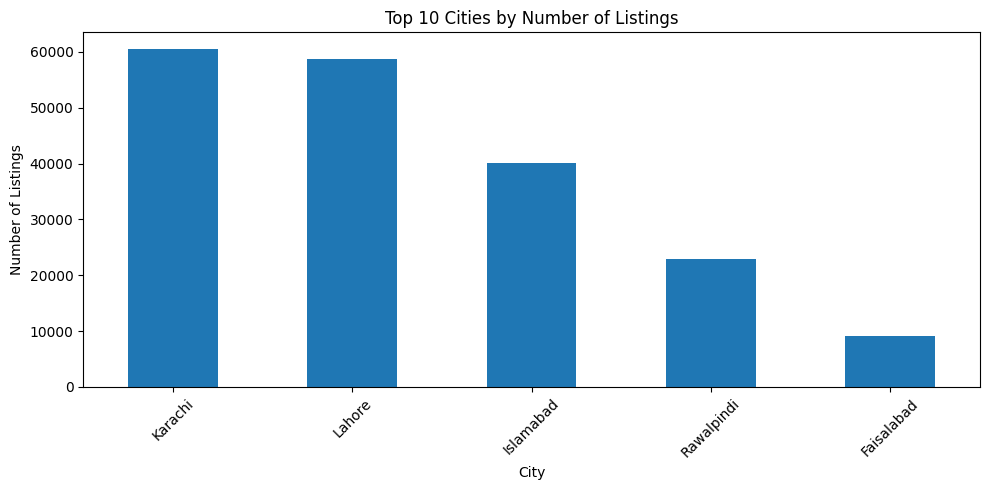

In [23]:
top_cities = df["city"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Number of Listings")
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Property type distribution

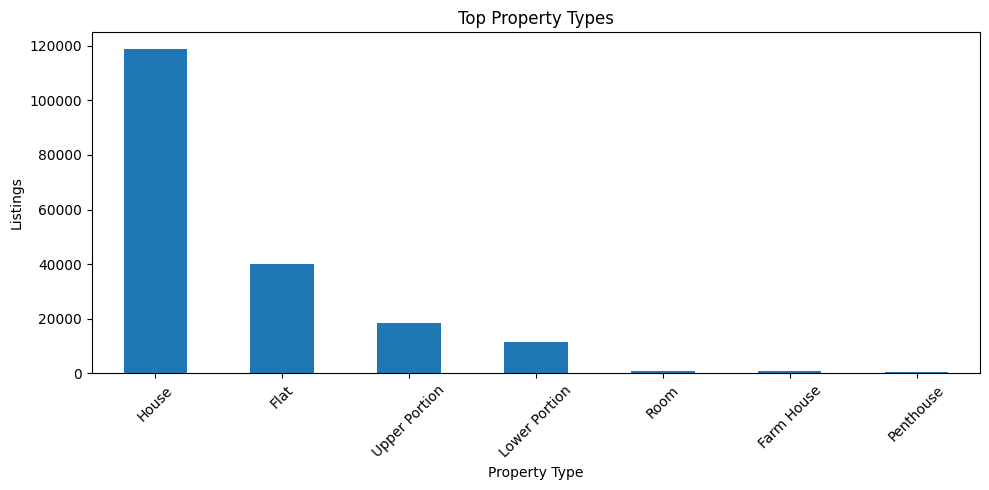

In [24]:
df["property_type"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top Property Types")
plt.xlabel("Property Type")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("Property.csv", sep=";")

# ----------------------------
# Basic cleaning / transformation
# ----------------------------

# Convert date
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Fill missing text fields (optional but useful)
df["agency"] = df["agency"].fillna("Unknown")
df["agent"] = df["agent"].fillna("Unknown")

# Trim text spaces
text_cols = ["property_type", "location", "city", "province_name", "purpose", "agency", "agent", "area"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Split area into value + unit
area_split = df["area"].str.extract(r"([\d\.]+)\s*([A-Za-z]+)")
df["area_value"] = pd.to_numeric(area_split[0], errors="coerce")
df["area_unit"] = area_split[1].str.title()

# Standardize area to marla
df["area_marla"] = np.where(
    df["area_unit"] == "Kanal",
    df["area_value"] * 20,
    np.where(df["area_unit"] == "Marla", df["area_value"], np.nan)
)

# Extra useful metrics
df["price_million"] = df["price"] / 1_000_000
df["price_per_marla"] = df["price"] / df["area_marla"]

# Sale-only data for fair price comparisons
sale_df = df[df["purpose"].str.lower() == "for sale"].copy()

print("Data ready:", df.shape)

Data ready: (191393, 22)


# Q1) Which city has the most property listings?


Q1 - Listings by City
         City  Listings
0     Karachi     60484
1      Lahore     58736
2   Islamabad     40195
3  Rawalpindi     22898
4  Faisalabad      9080


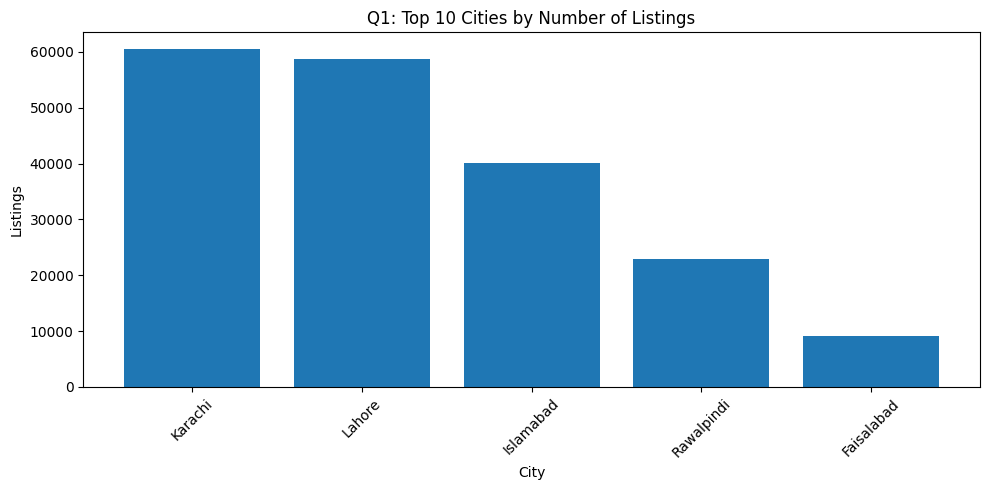

In [37]:
q1 = df["city"].value_counts().reset_index()
q1.columns = ["City", "Listings"]
print("\nQ1 - Listings by City")
print(q1.head(10))

plt.figure(figsize=(10,5))
plt.bar(q1["City"].head(10), q1["Listings"].head(10))
plt.title("Q1: Top 10 Cities by Number of Listings")
plt.xlabel("City")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q2) Which city has the highest median property price? (Best done on sale listings)


Q2 - Median Sale Price by City
         City  Median Price  Median Price (Million)
0   Islamabad    16000000.0                    16.0
1      Lahore    16000000.0                    16.0
2     Karachi    12500000.0                    12.5
3  Rawalpindi    11000000.0                    11.0
4  Faisalabad     9500000.0                     9.5


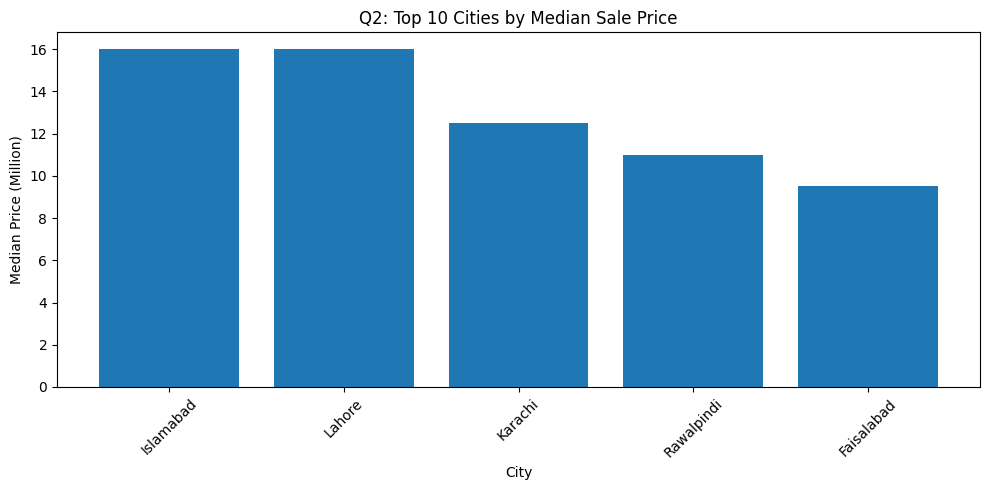

In [38]:
q2 = sale_df.groupby("city")["price"].median().sort_values(ascending=False).reset_index()
q2.columns = ["City", "Median Price"]
q2["Median Price (Million)"] = (q2["Median Price"] / 1_000_000).round(2)
print("\nQ2 - Median Sale Price by City")
print(q2.head(10))

plt.figure(figsize=(10,5))
plt.bar(q2["City"].head(10), q2["Median Price (Million)"].head(10))
plt.title("Q2: Top 10 Cities by Median Sale Price")
plt.xlabel("City")
plt.ylabel("Median Price (Million)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q3) Which property type is most common?


Q3 - Property Type Counts
   Property Type  Listings
0          House    118915
1           Flat     40157
2  Upper Portion     18475
3  Lower Portion     11693
4           Room      1029
5     Farm House       725
6      Penthouse       399


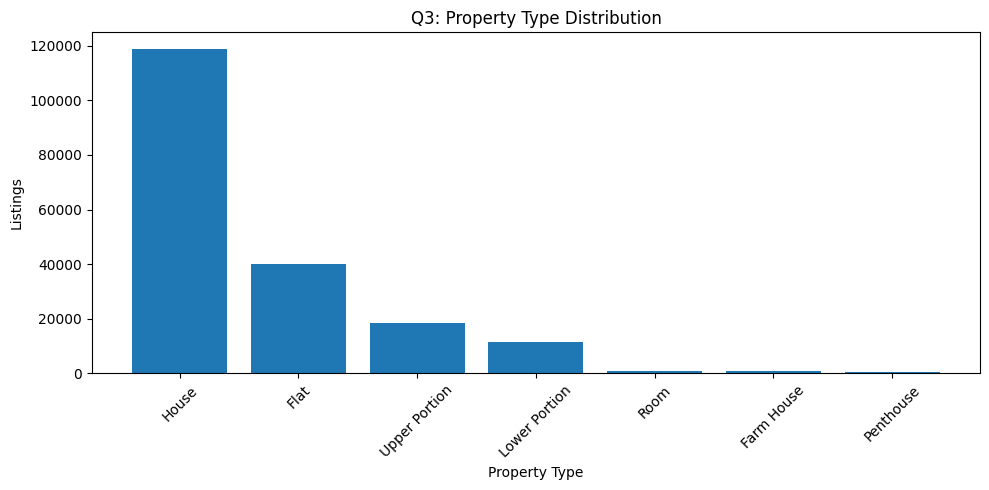

In [39]:
q3 = df["property_type"].value_counts().reset_index()
q3.columns = ["Property Type", "Listings"]
print("\nQ3 - Property Type Counts")
print(q3)

plt.figure(figsize=(10,5))
plt.bar(q3["Property Type"], q3["Listings"])
plt.title("Q3: Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q4) What is the split between rent and sale listings?


Q4 - Purpose Split
    Purpose  Listings  Percentage
0  For Sale    127018       66.37
1  For Rent     64375       33.63


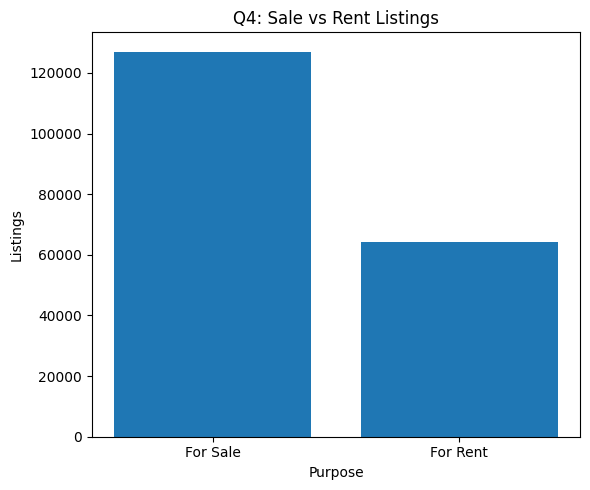

In [40]:
q4 = df["purpose"].value_counts(dropna=False).reset_index()
q4.columns = ["Purpose", "Listings"]
q4["Percentage"] = (q4["Listings"] / q4["Listings"].sum() * 100).round(2)
print("\nQ4 - Purpose Split")
print(q4)

plt.figure(figsize=(6,5))
plt.bar(q4["Purpose"], q4["Listings"])
plt.title("Q4: Sale vs Rent Listings")
plt.xlabel("Purpose")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()

# Q6) Are larger properties always more expensive?



Q6 - Price by Size Group (Sale)
  Size Group  Listings  Median_Price     Avg_Price  Median Price (Million)  \
0        <=5     54093     7000000.0  8.313407e+06                     7.0   
1       5-10     42468    16000000.0  1.812639e+07                    16.0   
2      10-20     23851    41000000.0  4.624550e+07                    41.0   
3      20-40      4918    95000000.0  1.097719e+08                    95.0   
4        40+      1674   125000000.0  1.669122e+08                   125.0   

   Avg Price (Million)  
0                 8.31  
1                18.13  
2                46.25  
3               109.77  
4               166.91  
Correlation (area vs price): 0.149


C:\Users\PMYLS\AppData\Local\Temp\ipykernel_14876\3745695726.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q6 = q6_data.groupby("Size Group").agg(


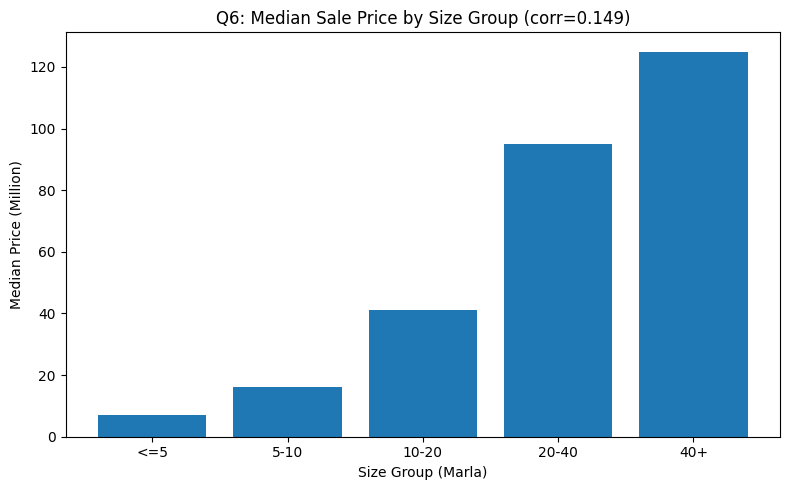

In [42]:
q6_data = sale_df[(sale_df["area_marla"] > 0) & (sale_df["price"] > 0)].copy()
corr_value = q6_data["area_marla"].corr(q6_data["price"])

bins = [0, 5, 10, 20, 40, np.inf]
labels = ["<=5", "5-10", "10-20", "20-40", "40+"]
q6_data["Size Group"] = pd.cut(q6_data["area_marla"], bins=bins, labels=labels, include_lowest=True)

q6 = q6_data.groupby("Size Group").agg(
    Listings=("property_id", "count"),
    Median_Price=("price", "median"),
    Avg_Price=("price", "mean")
).reset_index()

q6["Median Price (Million)"] = (q6["Median_Price"] / 1_000_000).round(2)
q6["Avg Price (Million)"] = (q6["Avg_Price"] / 1_000_000).round(2)

print("\nQ6 - Price by Size Group (Sale)")
print(q6)
print("Correlation (area vs price):", round(corr_value, 3))

plt.figure(figsize=(8,5))
plt.bar(q6["Size Group"], q6["Median Price (Million)"])
plt.title(f"Q6: Median Sale Price by Size Group (corr={corr_value:.3f})")
plt.xlabel("Size Group (Marla)")
plt.ylabel("Median Price (Million)")
plt.tight_layout()
plt.show()